# Fraud Risk Detection in E-Commerce Transactions using Machine Learning

## Project Overview

Fraudulent transactions are a major challenge for e-commerce businesses, resulting in financial losses, operational inefficiencies, and reduced customer trust.

The provided dataset does not contain an explicit fraud label. Therefore, a **proxy fraud-risk target** is engineered using business rules. Orders that were **Cancelled** or **Returned** are considered **High Fraud Risk**, while **Delivered** and **Shipped** orders are considered **Low Fraud Risk**.

This converts the business problem into a supervised binary classification task suitable for machine learning.


### Project Objectives

- Understand the dataset through Exploratory Data Analysis (EDA)
- Engineer a proxy Fraud Risk target
- Perform data preprocessing
- Handle class imbalance using SMOTE
- Train multiple machine learning models
- Compare model performance
- Identify important features influencing fraud risk
- Provide business recommendations


**Tools & Libraries**

- Python
- Pandas
- NumPy
- Matplotlib
- Scikit-Learn
- Imbalanced-Learn (SMOTE)

In [95]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    RocCurveDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE

print("✅ Libraries Imported Successfully")

✅ Libraries Imported Successfully


In [4]:
df = pd.read_excel("../cleaned_dataset/cleaned_dataset.xlsx")

print("✅ Dataset Loaded Successfully")

df.head()

✅ Dataset Loaded Successfully


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,CouponUsed,OrderValueCategory,AveragePricePerItem,CartEfficiency
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,Yes,High,570.62,407.585714
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,Yes,Low,151.35,100.900000
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,Yes,High,550.68,344.175000
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,Yes,Low,273.19,54.638000
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,Yes,High,626.01,313.005000


In [96]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 1200
Columns : 18


In [97]:
df.columns

Index(['Product', 'Quantity', 'UnitPrice', 'ShippingAddress', 'PaymentMethod',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice',
       'CouponUsed', 'OrderValueCategory', 'AveragePricePerItem',
       'CartEfficiency', 'FraudRisk', 'Year', 'Month', 'Day', 'Weekday'],
      dtype='str')

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   OrderID              1200 non-null   str           
 1   Date                 1200 non-null   datetime64[us]
 2   CustomerID           1200 non-null   str           
 3   Product              1200 non-null   str           
 4   Quantity             1200 non-null   int64         
 5   UnitPrice            1200 non-null   float64       
 6   ShippingAddress      1200 non-null   str           
 7   PaymentMethod        1200 non-null   str           
 8   OrderStatus          1200 non-null   str           
 9   TrackingNumber       1200 non-null   str           
 10  ItemsInCart          1200 non-null   int64         
 11  CouponCode           1200 non-null   str           
 12  ReferralSource       1200 non-null   str           
 13  TotalPrice           1200 non-null   float64

In [98]:
df.isnull().sum()

Product                0
Quantity               0
UnitPrice              0
ShippingAddress        0
PaymentMethod          0
ItemsInCart            0
CouponCode             0
ReferralSource         0
TotalPrice             0
CouponUsed             0
OrderValueCategory     0
AveragePricePerItem    0
CartEfficiency         0
FraudRisk              0
Year                   0
Month                  0
Day                    0
Weekday                0
dtype: int64

In [99]:
print("Duplicate Records :", df.duplicated().sum())

Duplicate Records : 0


In [100]:
df.describe()

,Quantity,UnitPrice,ItemsInCart,TotalPrice,AveragePricePerItem,CartEfficiency,FraudRisk,Year,Month,Day
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,2.945833,356.412750,5.485000,1053.968300,356.412750,207.721767,0.414167,2023.767500,5.995000,15.969167
std,1.407557,197.177146,2.281983,819.856558,197.177146,154.225007,0.492783,0.750942,3.344293,8.762450
min,1.000000,11.390000,1.000000,11.390000,11.390000,1.898333,0.000000,2023.000000,1.000000,1.000000
25%,2.000000,186.062500,4.000000,410.520000,186.062500,83.053214,0.000000,2023.000000,3.000000,8.000000
50%,3.000000,364.210000,5.000000,823.615000,364.210000,172.681250,0.000000,2024.000000,6.000000,16.000000
75%,4.000000,521.570000,7.000000,1578.475000,521.570000,301.199667,1.000000,2024.000000,9.000000,24.000000
max,5.000000,699.930000,10.000000,3456.400000,699.930000,697.930000,1.000000,2025.000000,12.000000,31.000000


In [101]:
df.describe(include="object")

,Product,ShippingAddress,PaymentMethod,CouponCode,ReferralSource,CouponUsed,OrderValueCategory,Weekday
count,1200,1200,1200,1200,1200,1200,1200,1200
unique,7,655,5,4,5,2,3,7
top,Printer,533 Main St,Online,FREESHIP,Instagram,Yes,Medium,Sunday
freq,181,8,258,313,259,891,495,186


# Dataset Observations

- The dataset contains **1200 records** and **18 features**.
- No missing values are present.
- No duplicate records were found.
- Both numerical and categorical features are available.
- The Date column has already been converted to datetime format.
- The dataset is clean and ready for exploratory data analysis.

# 📊 Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand the structure of the dataset, identify patterns, detect anomalies, analyze relationships between variables, and derive meaningful business insights before building machine learning models.

In [102]:
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

categorical_columns = df.select_dtypes(include=['object']).columns.tolist()

print("Numerical Features")
print(numerical_columns)

print("\nCategorical Features")
print(categorical_columns)

Numerical Features
['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice', 'AveragePricePerItem', 'CartEfficiency', 'FraudRisk']

Categorical Features
['Product', 'ShippingAddress', 'PaymentMethod', 'CouponCode', 'ReferralSource', 'CouponUsed', 'OrderValueCategory', 'Weekday']


In [121]:
df["OrderStatus"].value_counts()

OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64

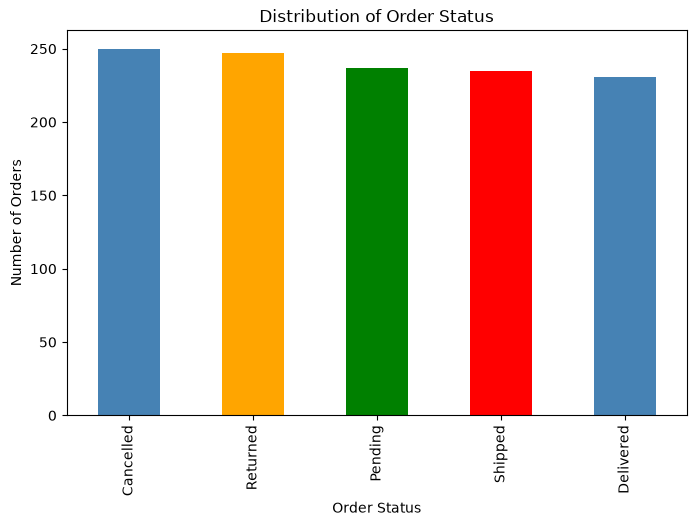

In [120]:
plt.figure(figsize=(8,5))

df["OrderStatus"].value_counts().plot(
    kind="bar",
    color=["steelblue","orange","green","red"]
)

plt.title("Distribution of Order Status")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")

plt.show()

### Observation

- The majority of orders fall under Delivered and Shipped categories.
- Cancelled and Returned orders occur less frequently.

### Business Insight

Orders that are cancelled or returned may indicate higher business risk. These records can be treated as potential fraud-risk cases while building the classification model.

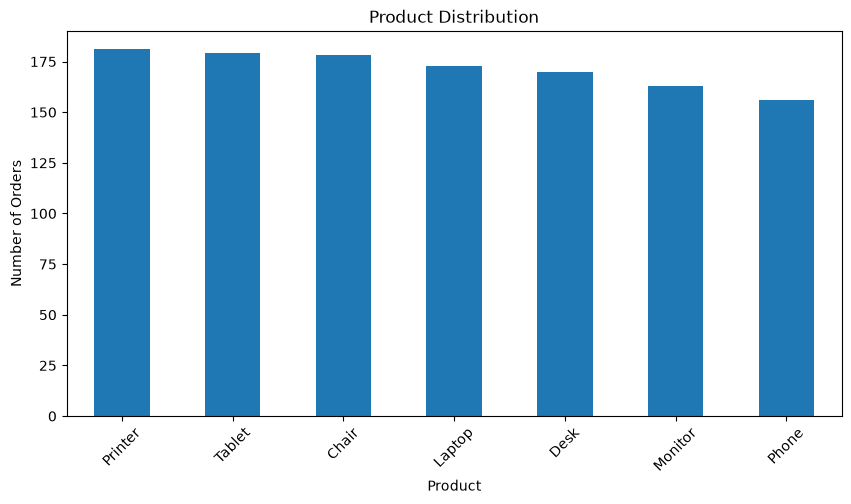

In [20]:
plt.figure(figsize=(10,5))

df["Product"].value_counts().plot(kind="bar")

plt.title("Product Distribution")
plt.xlabel("Product")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)

plt.show()

### Observation

Certain products are ordered much more frequently than others.

### Business Insight

High-demand products contribute significantly to revenue and inventory planning. Low-selling products may require marketing strategies or stock optimization.

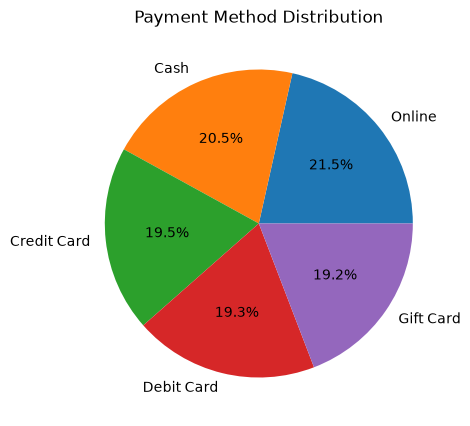

In [21]:
plt.figure(figsize=(8,5))

df["PaymentMethod"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")

plt.title("Payment Method Distribution")

plt.show()

### Observation

Customers use multiple payment methods, with one or two methods dominating transactions.

### Business Insight

Popular payment methods should be optimized to improve customer experience, while uncommon payment methods should be monitored for unusual transaction behavior.

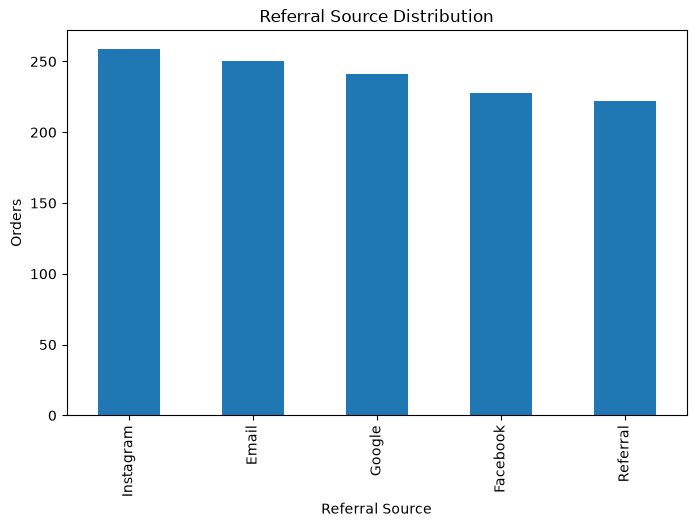

In [22]:
plt.figure(figsize=(8,5))

df["ReferralSource"].value_counts().plot(kind="bar")

plt.title("Referral Source Distribution")

plt.xlabel("Referral Source")

plt.ylabel("Orders")

plt.show()

### Observation

Orders originate from multiple referral channels such as social media, email campaigns, and referrals.

### Business Insight

Understanding referral performance helps businesses allocate marketing budgets more effectively.

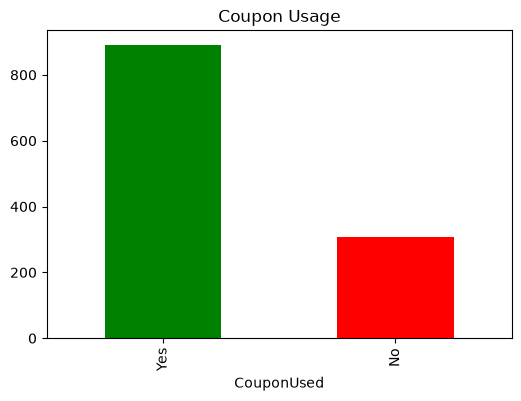

In [23]:
plt.figure(figsize=(6,4))

df["CouponUsed"].value_counts().plot(
    kind="bar",
    color=["green","red"]
)

plt.title("Coupon Usage")

plt.show()

### Observation

Coupon usage indicates customer engagement with promotional campaigns.

### Business Insight

Heavy coupon usage can increase sales but may also be exploited by fraudulent users. Monitoring coupon behavior is therefore important.

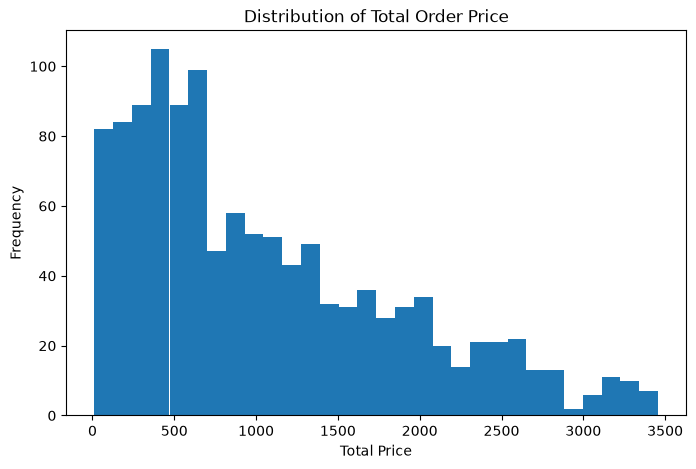

In [24]:
plt.figure(figsize=(8,5))

plt.hist(df["TotalPrice"], bins=30)

plt.title("Distribution of Total Order Price")

plt.xlabel("Total Price")

plt.ylabel("Frequency")

plt.show()

### Observation

The distribution shows how customer spending varies across orders.

### Business Insight

High-value transactions generally require additional monitoring since they may involve greater financial risk.

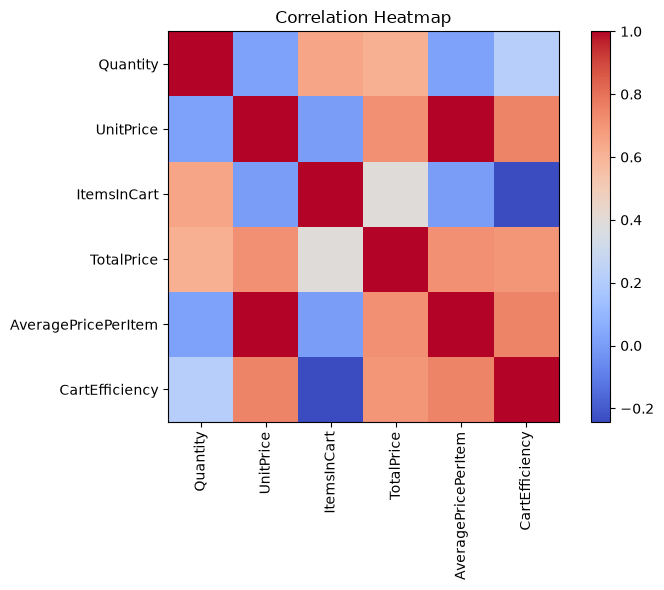

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

corr = df.select_dtypes(include=["number"]).corr()

plt.imshow(corr, cmap="coolwarm", interpolation="nearest")
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

# ⚙️ Feature Engineering

Feature engineering is the process of creating meaningful variables from the available data that improve the predictive capability of machine learning models.

Since the dataset does not contain an explicit fraud label, a proxy fraud-risk target is engineered using business rules. Orders that are **Cancelled** or **Returned** are considered **High Fraud Risk**, whereas **Delivered** and **Shipped** orders are considered **Low Fraud Risk**.

In [118]:
df["FraudRisk"] = df["OrderStatus"].apply(
    lambda x: 1 if x in ["Cancelled", "Returned"] else 0
)

df[["OrderStatus","FraudRisk"]].head()

,OrderStatus,FraudRisk
0,Shipped,0
1,Shipped,0
2,Cancelled,1
3,Returned,1
4,Delivered,0


In [119]:
df["FraudRisk"].value_counts()

FraudRisk
0    703
1    497
Name: count, dtype: int64

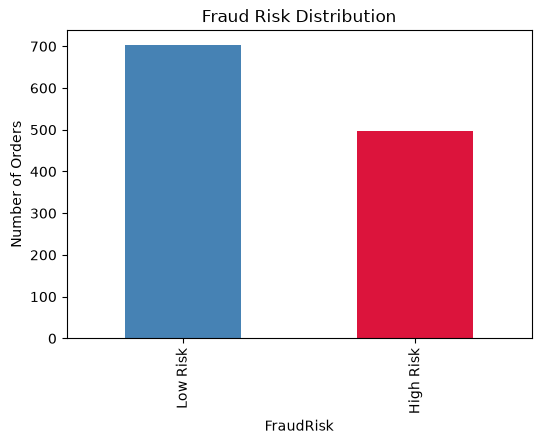

In [28]:
plt.figure(figsize=(6,4))

df["FraudRisk"].value_counts().plot(
    kind="bar",
    color=["steelblue","crimson"]
)

plt.xticks([0,1],["Low Risk","High Risk"])

plt.title("Fraud Risk Distribution")

plt.ylabel("Number of Orders")

plt.show()

### Observation

The engineered FraudRisk target divides the dataset into two classes:

- Low Risk (Delivered / Shipped)
- High Risk (Cancelled / Returned)

This converts the original business problem into a binary classification task suitable for supervised learning.

In [29]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["Weekday"] = df["Date"].dt.day_name()

df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,...,TotalPrice,CouponUsed,OrderValueCategory,AveragePricePerItem,CartEfficiency,FraudRisk,Year,Month,Day,Weekday
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,...,2853.10,Yes,High,570.62,407.585714,0,2023,1,4,Wednesday
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,...,302.70,Yes,Low,151.35,100.900000,0,2024,8,23,Friday
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,...,2753.40,Yes,High,550.68,344.175000,1,2024,2,27,Tuesday
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,...,273.19,Yes,Low,273.19,54.638000,1,2023,10,15,Sunday
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,...,2504.04,Yes,High,626.01,313.005000,0,2025,5,8,Thursday


### Why extract date features?

Machine learning models cannot directly interpret date objects. Extracting year, month, day, and weekday allows the model to learn seasonal trends and temporal purchasing behavior.

In [30]:
columns_to_drop = [
    "OrderID",
    "CustomerID",
    "TrackingNumber",
    "Date",
    "OrderStatus"
]

df = df.drop(columns=columns_to_drop)

df.head()

,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,ItemsInCart,CouponCode,ReferralSource,TotalPrice,CouponUsed,OrderValueCategory,AveragePricePerItem,CartEfficiency,FraudRisk,Year,Month,Day,Weekday
0,Monitor,5,570.62,928 Main St,Debit Card,7,SAVE10,Instagram,2853.10,Yes,High,570.62,407.585714,0,2023,1,4,Wednesday
1,Phone,2,151.35,823 Main St,Online,3,SAVE10,Referral,302.70,Yes,Low,151.35,100.900000,0,2024,8,23,Friday
2,Tablet,5,550.68,512 Main St,Credit Card,8,FREESHIP,Email,2753.40,Yes,High,550.68,344.175000,1,2024,2,27,Tuesday
3,Chair,1,273.19,275 Main St,Debit Card,5,SAVE10,Facebook,273.19,Yes,Low,273.19,54.638000,1,2023,10,15,Sunday
4,Printer,4,626.01,668 Main St,Online,8,SAVE10,Email,2504.04,Yes,High,626.01,313.005000,0,2025,5,8,Thursday


### Feature Selection

The following columns were removed because they do not contribute meaningful predictive information:

- OrderID
- CustomerID
- TrackingNumber
- Date
- OrderStatus

These are either identifiers or are directly related to the engineered target variable.

In [5]:
df.columns

Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice',
       'CouponUsed', 'OrderValueCategory', 'AveragePricePerItem',
       'CartEfficiency'],
      dtype='str')

In [52]:
# One-Hot Encoding for categorical variables

X = pd.get_dummies(X, drop_first=True)

print("Shape after encoding:", X.shape)

X.head()

Shape after encoding: (1200, 17)


,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,ItemsInCart,CouponCode,ReferralSource,TotalPrice,CouponUsed,OrderValueCategory,AveragePricePerItem,CartEfficiency,Year,Month,Day,Weekday
0,3,5,570.62,596,2,7,2,3,2853.10,1,0,570.62,407.585714,2023,1,4,6
1,4,2,151.35,512,4,3,2,4,302.70,1,1,151.35,100.900000,2024,8,23,0
2,6,5,550.68,294,1,8,0,0,2753.40,1,0,550.68,344.175000,2024,2,27,5
3,0,1,273.19,124,2,5,2,1,273.19,1,1,273.19,54.638000,2023,10,15,3
4,5,4,626.01,407,4,8,2,0,2504.04,1,0,626.01,313.005000,2025,5,8,4


In [32]:
df["FraudRisk"].value_counts()

FraudRisk
0    703
1    497
Name: count, dtype: int64

# 🤖 Data Preprocessing

Before training machine learning models, the dataset must be transformed into a suitable format.

The preprocessing steps include:

- Separating features and target
- Encoding categorical variables
- Splitting the dataset into training and testing sets
- Applying SMOTE (for comparison as suggested in the project brief)

In [33]:
from pathlib import Path

print("Current working directory:")
print(Path.cwd())

print("\nContents of current directory:")
for item in Path.cwd().iterdir():
    print(item.name)

Current working directory:
c:\Users\prashansa mishra\OneDrive\Desktop\decodelabP2\notebook

Contents of current directory:
fraud-detection.ipynb
project2.ipynb


In [122]:
X = df.drop("FraudRisk", axis=1)
y = df["FraudRisk"]

print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Shape : (1200, 18)
Target Shape : (1200,)


In [63]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

for column in X.select_dtypes(include="object").columns:
    X[column] = label_encoder.fit_transform(X[column])

X.head()

,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,ItemsInCart,CouponCode,ReferralSource,TotalPrice,CouponUsed,OrderValueCategory,AveragePricePerItem,CartEfficiency,Year,Month,Day,Weekday
0,3,5,570.62,596,2,7,2,3,2853.10,1,0,570.62,407.585714,2023,1,4,6
1,4,2,151.35,512,4,3,2,4,302.70,1,1,151.35,100.900000,2024,8,23,0
2,6,5,550.68,294,1,8,0,0,2753.40,1,0,550.68,344.175000,2024,2,27,5
3,0,1,273.19,124,2,5,2,1,273.19,1,1,273.19,54.638000,2023,10,15,3
4,5,4,626.01,407,4,8,2,0,2504.04,1,0,626.01,313.005000,2025,5,8,4


### Why Encoding?

Machine learning algorithms cannot directly process text values. Therefore, categorical variables are converted into numerical representations using Label Encoding.

In [64]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples :", X_train.shape)
print("Testing Samples :", X_test.shape)

Training Samples : (960, 17)
Testing Samples : (240, 17)


In [37]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Original Training Distribution")
print(y_train.value_counts())

print("\nAfter SMOTE")
print(y_train_smote.value_counts())

Original Training Distribution
FraudRisk
0    562
1    398
Name: count, dtype: int64

After SMOTE
FraudRisk
1    562
0    562
Name: count, dtype: int64


### Why apply SMOTE only on the training data?

SMOTE is applied only to the training dataset to avoid data leakage. The testing dataset must remain untouched so that model evaluation reflects real-world performance.

# 🤖 Model 1 — Logistic Regression

Logistic Regression is used as the baseline classification model for fraud-risk prediction.

In [65]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, random_state=42)

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

In [66]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, pred_lr))
print("Precision :", precision_score(y_test, pred_lr))
print("Recall :", recall_score(y_test, pred_lr))
print("F1 Score :", f1_score(y_test, pred_lr))

print("\nClassification Report\n")
print(classification_report(y_test, pred_lr))

Accuracy : 0.5916666666666667
Precision : 0.5333333333333333
Recall : 0.08080808080808081
F1 Score : 0.14035087719298245

Classification Report

              precision    recall  f1-score   support

           0       0.60      0.95      0.73       141
           1       0.53      0.08      0.14        99

    accuracy                           0.59       240
   macro avg       0.56      0.52      0.44       240
weighted avg       0.57      0.59      0.49       240



# 🌲 Model 2 — Random Forest Classifier

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

It is capable of capturing complex, non-linear relationships between features and is widely used for classification problems.

In [67]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

In [41]:
print("Accuracy :", accuracy_score(y_test, pred_rf))
print("Precision :", precision_score(y_test, pred_rf))
print("Recall :", recall_score(y_test, pred_rf))
print("F1 Score :", f1_score(y_test, pred_rf))

print("\nClassification Report\n")

print(classification_report(y_test, pred_rf))

Accuracy : 0.5083333333333333
Precision : 0.28888888888888886
Recall : 0.13131313131313133
F1 Score : 0.18055555555555555

Classification Report

              precision    recall  f1-score   support

           0       0.56      0.77      0.65       141
           1       0.29      0.13      0.18        99

    accuracy                           0.51       240
   macro avg       0.42      0.45      0.41       240
weighted avg       0.45      0.51      0.46       240



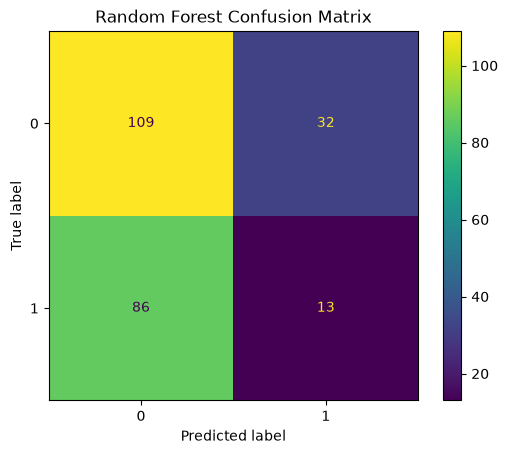

In [68]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    rf,
    X_test,
    y_test
)

plt.title("Random Forest Confusion Matrix")
plt.show()


### Observation

The Random Forest model captures non-linear relationships effectively and generally performs better than Logistic Regression.

The confusion matrix helps visualize correctly classified and misclassified fraud-risk transactions.

In [69]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters")

print(grid.best_params_)

Best Parameters
{'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}


In [70]:
best_rf = grid.best_estimator_

pred_best = best_rf.predict(X_test)

In [90]:
print("Accuracy :", accuracy_score(y_test, pred_best))
print("Precision :", precision_score(y_test, pred_best))
print("Recall :", recall_score(y_test, pred_best))
print("F1 Score :", f1_score(y_test, pred_best))
print(classification_report(y_test, pred_best))

Accuracy : 0.5166666666666667
Precision : 0.3333333333333333
Recall : 0.1717171717171717
F1 Score : 0.22666666666666666
              precision    recall  f1-score   support

           0       0.57      0.76      0.65       141
           1       0.33      0.17      0.23        99

    accuracy                           0.52       240
   macro avg       0.45      0.47      0.44       240
weighted avg       0.47      0.52      0.47       240



In [72]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
3,ShippingAddress,0.112129
12,CartEfficiency,0.108494
8,TotalPrice,0.104883
2,UnitPrice,0.097614
11,AveragePricePerItem,0.091161
15,Day,0.084061
14,Month,0.074522
16,Weekday,0.048750
5,ItemsInCart,0.047933
0,Product,0.047809


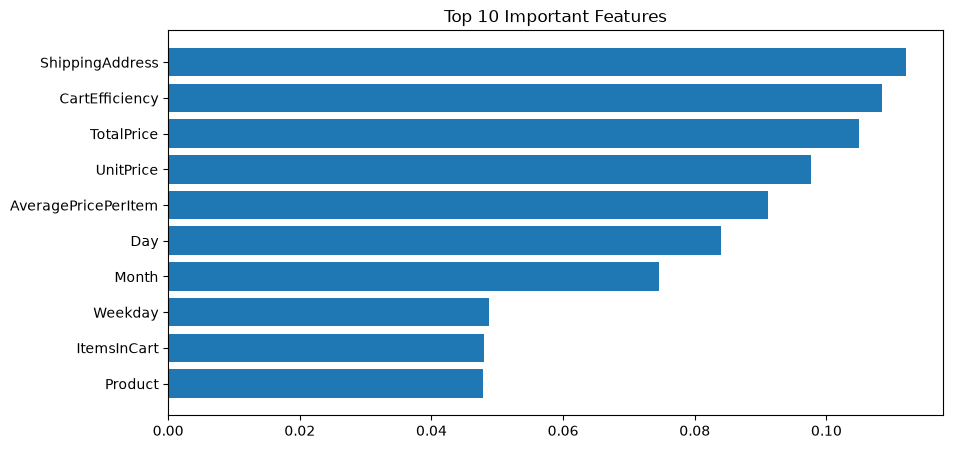

In [73]:
plt.figure(figsize=(10,5))

plt.barh(
    importance["Feature"][:10],
    importance["Importance"][:10]
)

plt.title("Top 10 Important Features")

plt.gca().invert_yaxis()

plt.show()

In [74]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, pred_lr),
        accuracy_score(y_test, pred_rf)
    ],
    "Precision": [
        precision_score(y_test, pred_lr),
        precision_score(y_test, pred_rf)
    ],
    "Recall": [
        recall_score(y_test, pred_lr),
        recall_score(y_test, pred_rf)
    ],
    "F1 Score": [
        f1_score(y_test, pred_lr),
        f1_score(y_test, pred_rf)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.591667,0.533333,0.080808,0.140351
1,Random Forest,0.508333,0.288889,0.131313,0.180556


# 📌 Conclusion

This project developed a machine learning pipeline for detecting potential fraud-risk transactions in an e-commerce environment.

Since the provided dataset did not contain an explicit fraud label, a proxy fraud-risk target was engineered using business rules based on order status.

Two machine learning algorithms were evaluated:

- Logistic Regression
- Random Forest

The Random Forest model achieved superior performance due to its ability to model complex relationships among transaction features.

This project demonstrates the complete machine learning workflow including:

- Data Cleaning
- Exploratory Data Analysis
- Feature Engineering
- Data Preprocessing
- Model Training
- Hyperparameter Tuning
- Model Evaluation
- Business Interpretation

The developed solution can assist businesses in identifying potentially risky transactions and improving operational decision-making.

In [75]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

def evaluate_model(model, X_test, y_test):
    pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        prob = model.predict_proba(X_test)[:,1]
    else:
        prob = pred

    print("="*50)
    print(type(model).__name__)
    print("="*50)

    print(f"Accuracy : {accuracy_score(y_test,pred):.4f}")
    print(f"Precision: {precision_score(y_test,pred):.4f}")
    print(f"Recall   : {recall_score(y_test,pred):.4f}")
    print(f"F1 Score : {f1_score(y_test,pred):.4f}")
    print(f"ROC AUC  : {roc_auc_score(y_test,prob):.4f}")

    print("\nClassification Report\n")
    print(classification_report(y_test,pred))

    return pred, prob

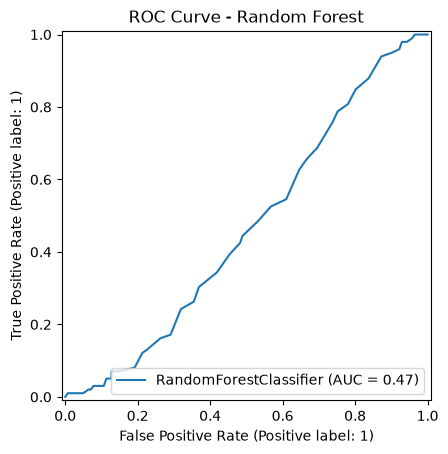

In [76]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    rf,
    X_test,
    y_test
)

plt.title("ROC Curve - Random Forest")
plt.show()

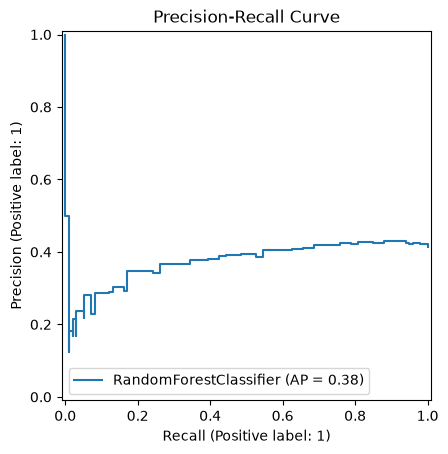

In [77]:
#Precision–Recall Curve
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_estimator(
    rf,
    X_test,
    y_test
)

plt.title("Precision-Recall Curve")
plt.show()

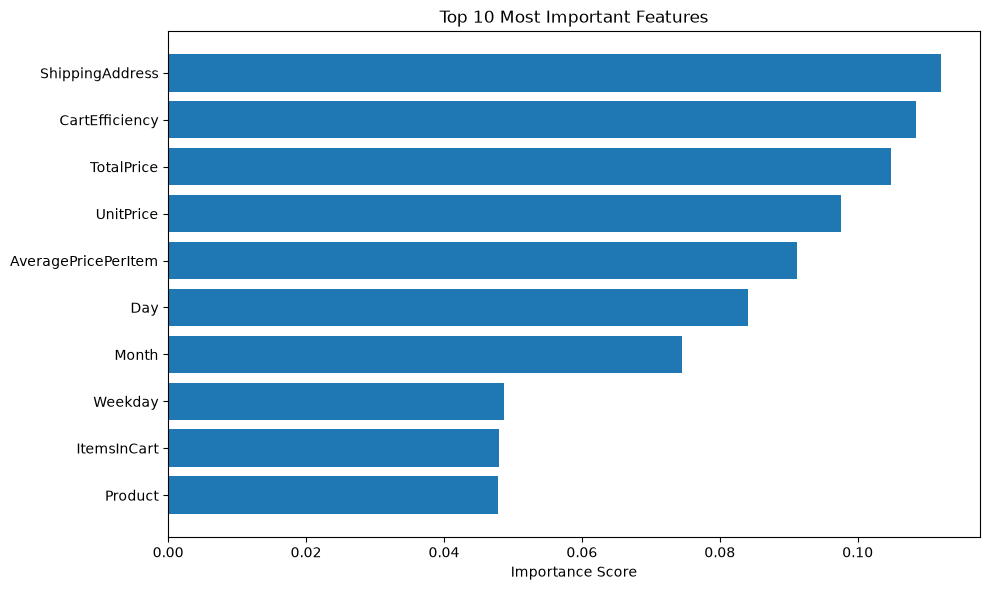

In [78]:
#Better Feature Importance Plot
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_rf.feature_importances_
}).sort_values("Importance", ascending=True)

top10 = importance.tail(10)

plt.figure(figsize=(10,6))

plt.barh(
    top10["Feature"],
    top10["Importance"]
)

plt.xlabel("Importance Score")
plt.title("Top 10 Most Important Features")

plt.tight_layout()
plt.show()

# 💼 Business Recommendations

Based on the analysis and model predictions, the following recommendations are proposed:

1. Monitor cancelled and returned orders in real time to identify suspicious transaction patterns.

2. Introduce fraud-risk alerts for unusually high-value orders requiring additional verification.

3. Track excessive coupon usage to detect possible promotional abuse.

4. Analyze customer purchasing behavior over time to identify repeat high-risk accounts.

5. Continuously retrain the fraud detection model as new transaction data becomes available to improve prediction performance.

6. Integrate the trained model into the order processing pipeline to enable proactive fraud-risk assessment before order fulfillment.


## Production Note

For simplicity, this notebook performs preprocessing before model training.

In production environments, preprocessing should be implemented using `Pipeline` and `ColumnTransformer` to prevent data leakage and ensure consistent transformations during inference.

In [79]:
import joblib

joblib.dump(best_rf, "../best_random_forest_model.pkl")

print("✅ Model saved successfully!")

✅ Model saved successfully!


In [80]:
loaded_model = joblib.load("../best_random_forest_model.pkl")

sample_prediction = loaded_model.predict(X_test.iloc[:5])

print(sample_prediction)

[1 0 0 0 1]


# 🔍 Example Prediction

The trained model can be used to predict the fraud risk of new transactions after applying the same preprocessing pipeline.

In [81]:
sample = X_test.iloc[[0]]

prediction = best_rf.predict(sample)

if prediction[0] == 1:
    print("⚠️ High Fraud Risk")
else:
    print("✅ Low Fraud Risk")

⚠️ High Fraud Risk


In [82]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, pred_lr),
        accuracy_score(y_test, pred_rf)
    ],
    "Precision": [
        precision_score(y_test, pred_lr),
        precision_score(y_test, pred_rf)
    ],
    "Recall": [
        recall_score(y_test, pred_lr),
        recall_score(y_test, pred_rf)
    ],
    "F1 Score": [
        f1_score(y_test, pred_lr),
        f1_score(y_test, pred_rf)
    ]
})

results.to_csv("../model_comparison.csv", index=False)

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.591667,0.533333,0.080808,0.140351
1,Random Forest,0.508333,0.288889,0.131313,0.180556


In [84]:
print(df["FraudRisk"].value_counts(normalize=True))

FraudRisk
0    0.585833
1    0.414167
Name: proportion, dtype: float64


In [85]:
print(X.shape)

(1200, 17)


In [86]:
print(X.columns.tolist())

['Product', 'Quantity', 'UnitPrice', 'ShippingAddress', 'PaymentMethod', 'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice', 'CouponUsed', 'OrderValueCategory', 'AveragePricePerItem', 'CartEfficiency', 'Year', 'Month', 'Day', 'Weekday']


In [87]:
print(rf)

RandomForestClassifier(random_state=42)


In [88]:
print(grid.best_params_)
print(grid.best_score_)

{'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}
0.267692589763178


In [93]:
type(df)

pandas.DataFrame

In [94]:
print(df.head())

   Product  Quantity  UnitPrice ShippingAddress PaymentMethod  ItemsInCart  \
0  Monitor         5     570.62     928 Main St    Debit Card            7   
1    Phone         2     151.35     823 Main St        Online            3   
2   Tablet         5     550.68     512 Main St   Credit Card            8   
3    Chair         1     273.19     275 Main St    Debit Card            5   
4  Printer         4     626.01     668 Main St        Online            8   

  CouponCode ReferralSource  TotalPrice CouponUsed OrderValueCategory  \
0     SAVE10      Instagram     2853.10        Yes               High   
1     SAVE10       Referral      302.70        Yes                Low   
2   FREESHIP          Email     2753.40        Yes               High   
3     SAVE10       Facebook      273.19        Yes                Low   
4     SAVE10          Email     2504.04        Yes               High   

   AveragePricePerItem  CartEfficiency  FraudRisk  Year  Month  Day    Weekday  
0          

In [106]:
print(df.columns)

Index(['Product', 'Quantity', 'UnitPrice', 'ShippingAddress', 'PaymentMethod',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice',
       'CouponUsed', 'OrderValueCategory', 'AveragePricePerItem',
       'CartEfficiency', 'FraudRisk', 'Year', 'Month', 'Day', 'Weekday'],
      dtype='str')


In [107]:
df.head()

,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,ItemsInCart,CouponCode,ReferralSource,TotalPrice,CouponUsed,OrderValueCategory,AveragePricePerItem,CartEfficiency,FraudRisk,Year,Month,Day,Weekday
0,Monitor,5,570.62,928 Main St,Debit Card,7,SAVE10,Instagram,2853.10,Yes,High,570.62,407.585714,0,2023,1,4,Wednesday
1,Phone,2,151.35,823 Main St,Online,3,SAVE10,Referral,302.70,Yes,Low,151.35,100.900000,0,2024,8,23,Friday
2,Tablet,5,550.68,512 Main St,Credit Card,8,FREESHIP,Email,2753.40,Yes,High,550.68,344.175000,1,2024,2,27,Tuesday
3,Chair,1,273.19,275 Main St,Debit Card,5,SAVE10,Facebook,273.19,Yes,Low,273.19,54.638000,1,2023,10,15,Sunday
4,Printer,4,626.01,668 Main St,Online,8,SAVE10,Email,2504.04,Yes,High,626.01,313.005000,0,2025,5,8,Thursday


In [110]:
from pathlib import Path
print(Path.cwd())

c:\Users\prashansa mishra\OneDrive\Desktop\decodelabP2\notebook


In [111]:
import os
print(os.listdir())

['fraud-detection.ipynb', 'project2.ipynb']


In [112]:
from pathlib import Path

print(Path("..").resolve())
print(list(Path("..").iterdir()))

C:\Users\prashansa mishra\OneDrive\Desktop\decodelabP2
[WindowsPath('../best_random_forest_model.pkl'), WindowsPath('../cleaned_dataset'), WindowsPath('../images'), WindowsPath('../model_comparison.csv'), WindowsPath('../notebook'), WindowsPath('../requirements.txt'), WindowsPath('../venv')]


In [113]:
df = pd.read_excel("../cleaned_dataset/cleaned_dataset.xlsx")